# Exploratory Data Analysis

Dengue federated analysis workshop.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ISARICResearch/Dissemination/blob/main/workshops/federated%20analytics/FederatedAnalysis_Project/notebooks/01_eda.ipynb)
<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/88ssarmiento/federated-analytics-workshop-dengue/blob/master/notebooks/01_eda.ipynb) -->

## Introduction

Exploratory data analysis (EDA) is the first step of any data analysis, used to understand a dataset before drawing conclusions from it. It combines summary tables and plots to review the dataset's structure, the meaning and quality of each variable, and how their values are distributed. It helps detect problems such as missing or inconsistent values early, and guides the decisions made in later analyses.

This notebook presents an exploratory analysis of the workshop's dummy dengue dataset, applying a series of procedures commonly used in data science for this purpose.

## Objective

Get to know the dengue dataset before the analyses in the following notebooks: its structure, variables, missing values, and the distribution of key clinical variables, both overall and within each of the 5 health institutions. Looking at each institution separately shows how their data differs, which matters for the federated approach used in the rest of the workshop.

## Table of Contents

```
1. Setup
    1.1. Environment detection
    1.2. Install dependencies
    1.3. Get project files
    1.4. Imports
    1.5. Load data
2. Data Overview
    2.1. About the dataset
    2.2. Structure
    2.3. Variable Overview
    2.4. Preview the data
3. Key Distributions
    3.1. Age
    3.2. Sex
    3.3. Final classification
    3.4. Hospitalized
    3.5. Outcome
```

## 1. Setup

Prepare everything the notebook needs before starting the analysis.

### 1.1. Environment detection

Check whether this notebook is running on Google Colab or on a local computer.

In [1]:
import sys

# True on Google Colab, False on a local computer
IN_COLAB = "google.colab" in sys.modules

### 1.2. Install dependencies

Install any extra packages this notebook needs. This step only runs on Google Colab. On a local computer, the packages are already installed.

In [2]:
# if IN_COLAB:
#     %pip install -q <package>

### 1.3. Get project files

Get the project's data and code. On Google Colab, only the project's folder is downloaded first from the repository where it's published; on a local computer, they're already available next to this notebook.

In [3]:
from pathlib import Path

# Repository the project is downloaded from on Google Colab (keep only one uncommented)
REPO_URL, PROJECT_PATH = "https://github.com/ISARICResearch/Dissemination.git", "workshops/federated analytics/FederatedAnalysis_Project"
# REPO_URL, PROJECT_PATH = "https://github.com/88ssarmiento/federated-analytics-workshop-dengue.git", ""
REPO_NAME = Path(REPO_URL).stem

if IN_COLAB:
    # Download only this project's folder, not the whole repository
    project_dir = Path(REPO_NAME) / PROJECT_PATH
    if not project_dir.exists():
        if PROJECT_PATH:
            !git clone --depth 1 --filter=blob:none --sparse {REPO_URL}
            !git -C {REPO_NAME} sparse-checkout set "{PROJECT_PATH}"
        else:
            !git clone --depth 1 {REPO_URL}
else:
    # This notebook already lives inside the project
    project_dir = Path("..")

# Make the project's own code importable (e.g. `analysis_lib`)
sys.path.insert(0, str(project_dir))

data_dir = project_dir / "data"
data_file = data_dir / "dummy_data.parquet"
dictionary_file = data_dir / "dummy_data_dictionary.json"

### 1.4. Imports

Load the Python libraries used in this notebook.

In [4]:
# Standard library
import json

# Third-party
import pandas as pd

# Project
from analysis_lib.eda import display_variable_overview, plot_distribution_by_site

# Show table content in full, without cutting it off
pd.set_option("display.max_colwidth", None)

### 1.5. Load data

Read the example data.

In [5]:
# Load the full example dataset
df = pd.read_parquet(data_file)

# Load the data dictionary that describes each column
with open(dictionary_file, encoding="utf-8") as f:
    data_dictionary = json.load(f)

## 2. Data Overview

Take a first look at the dataset before starting the detailed analysis.

### 2.1. About the dataset

This is an example (dummy) dataset of dengue patients treated at 5 different health institutions.

Its columns are grouped into categories:

- Identification
- Key dates
- Demographic data
- Exam information
- Treating institution
- Medical care provided and outcome
- Symptoms observed

### 2.2. Structure

Look at the dataset's overall shape: how many records and columns it has, and the data type of each column.

In [6]:
# Show the number of rows and columns, and each column's data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10284 entries, 0 to 10283
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   record_id             10284 non-null  str           
 1   consultation_date     10284 non-null  datetime64[us]
 2   symptom_onset_date    10284 non-null  datetime64[us]
 3   hospitalization_date  7077 non-null   datetime64[us]
 4   death_date            98 non-null     datetime64[us]
 5   age                   10284 non-null  int64         
 6   sex                   10284 non-null  string        
 7   tissue_sample_taken   7063 non-null   string        
 8   liver_sample          7060 non-null   string        
 9   spleen_sample         7060 non-null   string        
 10  lung_sample           7060 non-null   string        
 11  brain_sample          7060 non-null   string        
 12  myocardium_sample     7060 non-null   string        
 13  bone_marrow_sample    7060 

### 2.3. Variable Overview

Look at each column in detail, grouped by category: its meaning, data type and key statistics.

In [7]:
# Show each column's meaning and statistics, grouped by category
display_variable_overview(df, data_dictionary)

#### Identification

,Column,Description,Data type,Missing (n),Missing (%),Unique values
0,record_id,,str,0,0.0,10284 unique


#### Date

,Column,Description,Data type,Missing (n),Missing (%),Unique values
0,consultation_date,Consultation Date,datetime64[us],0,0.0,2612 unique
1,symptom_onset_date,Symptom Onset Date,datetime64[us],0,0.0,2615 unique
2,hospitalization_date,Hospitalization Date,datetime64[us],3207,31.2,2276 unique
3,death_date,Death Date,datetime64[us],10186,99.0,93 unique


#### Demographic

...

,Column,Description,Data type,Missing (n),Missing (%),Unique values
0,institution,Legal name or name of the UPGD [Unidad Primaria Generadora de Datos / Primary Data-Generating Unit],str,0,0.0,"H2: 5543 (53.9%), H3: 2464 (24.0%), H1: 1233 (12.0%), H5: 750 (7.3%), H4: 294 (2.9%)"


#### Medical Care

,Column,Description,Data type,Missing (n),Missing (%),Unique values
0,final_classification,Final Classification,string,0,0.0,"Dengue with warning signs: 5404 (52.5%), Dengue without warning signs: 4309 (41.9%), Severe dengue: 571 (5.6%)"
1,hospitalized,Hospitalized,string,0,0.0,"Yes: 7077 (68.8%), No: 3207 (31.2%)"
2,outcome,Final condition,string,0,0.0,"Alive: 10186 (99.0%), Dead: 98 (1.0%)"


#### Symptom

,Column,Description,Data type,Missing (n),Missing (%),Unique values
0,fever,Semiological findings - Fever,string,0,0.0,Yes: 10284 (100.0%)
1,myalgia,Semiological findings - Myalgia,string,0,0.0,"Yes: 9436 (91.8%), No: 848 (8.2%)"
2,arthralgia,Semiological findings - Arthralgia,string,0,0.0,"Yes: 8267 (80.4%), No: 2017 (19.6%)"
3,headache,Semiological findings - Headache,string,0,0.0,"Yes: 7619 (74.1%), No: 2665 (25.9%)"
4,retro_orbital_pain,Semiological findings - Retro-orbital pain,string,0,0.0,"No: 6795 (66.1%), Yes: 3489 (33.9%)"
5,abdominal_pain,Semiological findings - Abdominal pain,string,2,0.0,"No: 6450 (62.7%), Yes: 3832 (37.3%)"
6,vomiting,Semiological findings - Vomiting,string,2,0.0,"No: 7828 (76.1%), Yes: 2454 (23.9%)"
7,diarrhea,Semiological findings - Diarrhea,string,2,0.0,"No: 8486 (82.5%), Yes: 1796 (17.5%)"
8,rash,Semiological findings - Rash,string,0,0.0,"No: 8066 (78.4%), Yes: 2218 (21.6%)"
9,petechiae,Semiological findings - Petechiae,string,9986,97.1,"No: 270 (90.6%), Yes: 28 (9.4%)"


### 2.4. Preview the data

Show a few example records, indexed by record_id.

In [8]:
# Show the first 5 records, one column per row given how many columns there are.
# Index by record_id so it isn't duplicated as a separate row/column either way.
df.head().set_index("record_id")

,consultation_date,symptom_onset_date,hospitalization_date,death_date,age,sex,tissue_sample_taken,liver_sample,spleen_sample,lung_sample,...,postural_hypotension,hypothermia,lethargy,hepatomegaly,platelet_drop,fluid_accumulation,hematocrit_increase,plasma_leakage,severe_bleeding,organ_damage
record_id,,,,,,,,,,,,,,,,,,,,,
0,2011-01-13,2011-01-11,NaT,NaT,25,Male,<NA>,<NA>,<NA>,<NA>,...,No,<NA>,<NA>,No,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2011-01-30,2011-01-24,NaT,NaT,15,Male,<NA>,<NA>,<NA>,<NA>,...,No,<NA>,<NA>,No,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2011-09-16,2011-09-14,NaT,NaT,22,Male,<NA>,<NA>,<NA>,<NA>,...,No,<NA>,<NA>,No,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2011-07-21,2011-07-18,2011-07-21,NaT,49,Male,<NA>,<NA>,<NA>,<NA>,...,Yes,<NA>,<NA>,No,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2011-12-05,2011-11-29,NaT,NaT,24,Male,<NA>,<NA>,<NA>,<NA>,...,No,<NA>,<NA>,No,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 3. Key Distributions

Look at how a few clinically relevant variables are distributed, in total and across each of the 5 institutions.

### 3.1. Age

Age grouped into 10-year ranges.

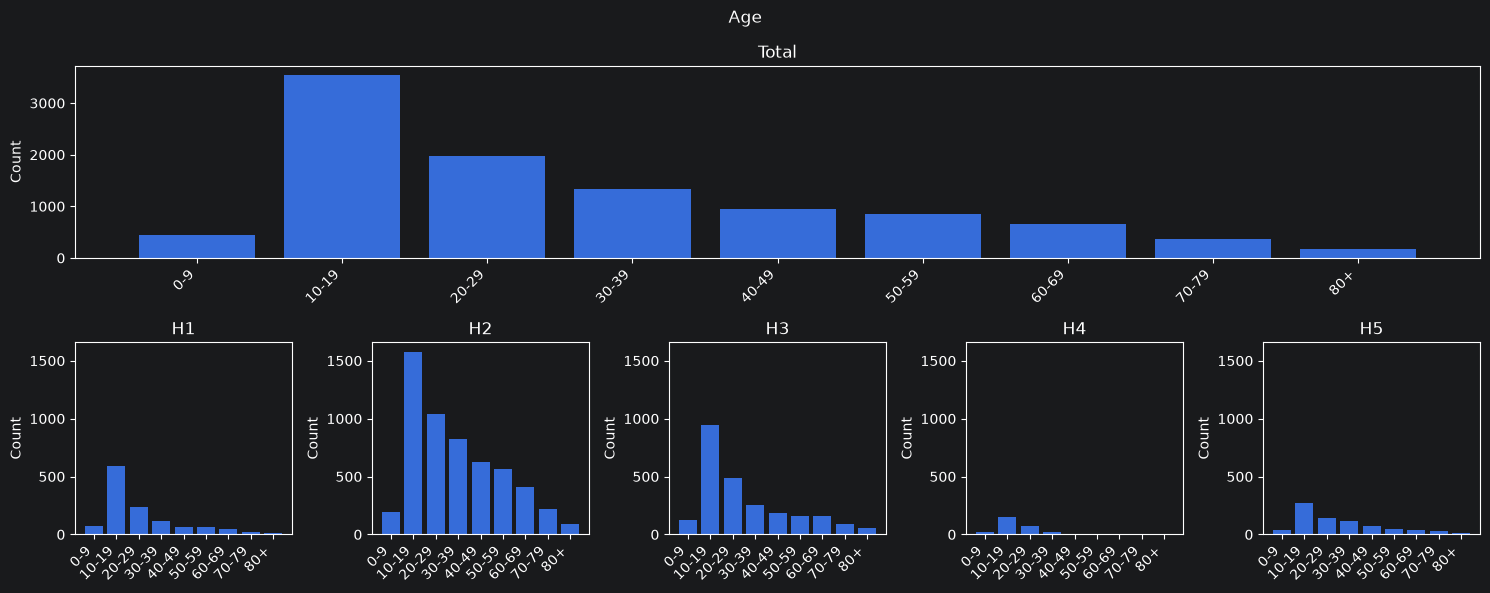

In [9]:
plot_distribution_by_site(
    df,
    column="age",
    site_column="institution",
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 120],
    bin_labels=["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"],
    title="Age",
    normalize=False
)

### 3.2. Sex

Sex distribution.

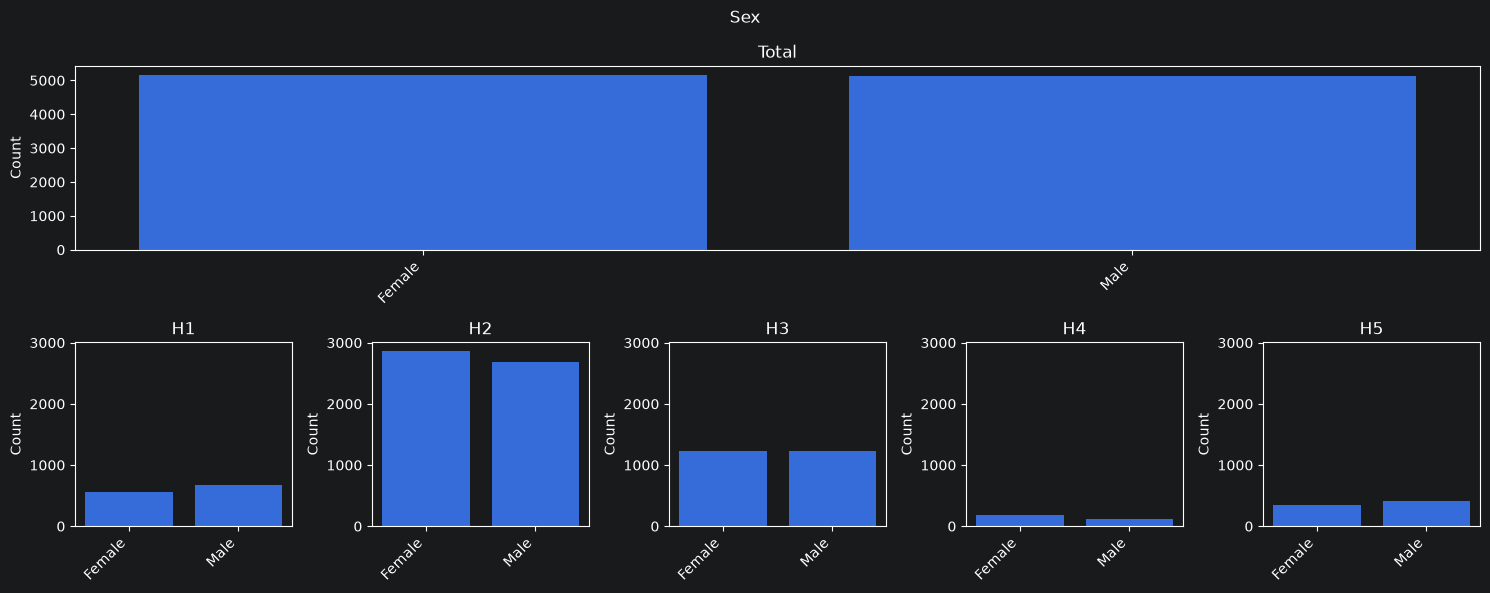

In [10]:
plot_distribution_by_site(
    df, column="sex", site_column="institution", title="Sex", normalize=False
)

### 3.3. Final classification

Severity classification at diagnosis.

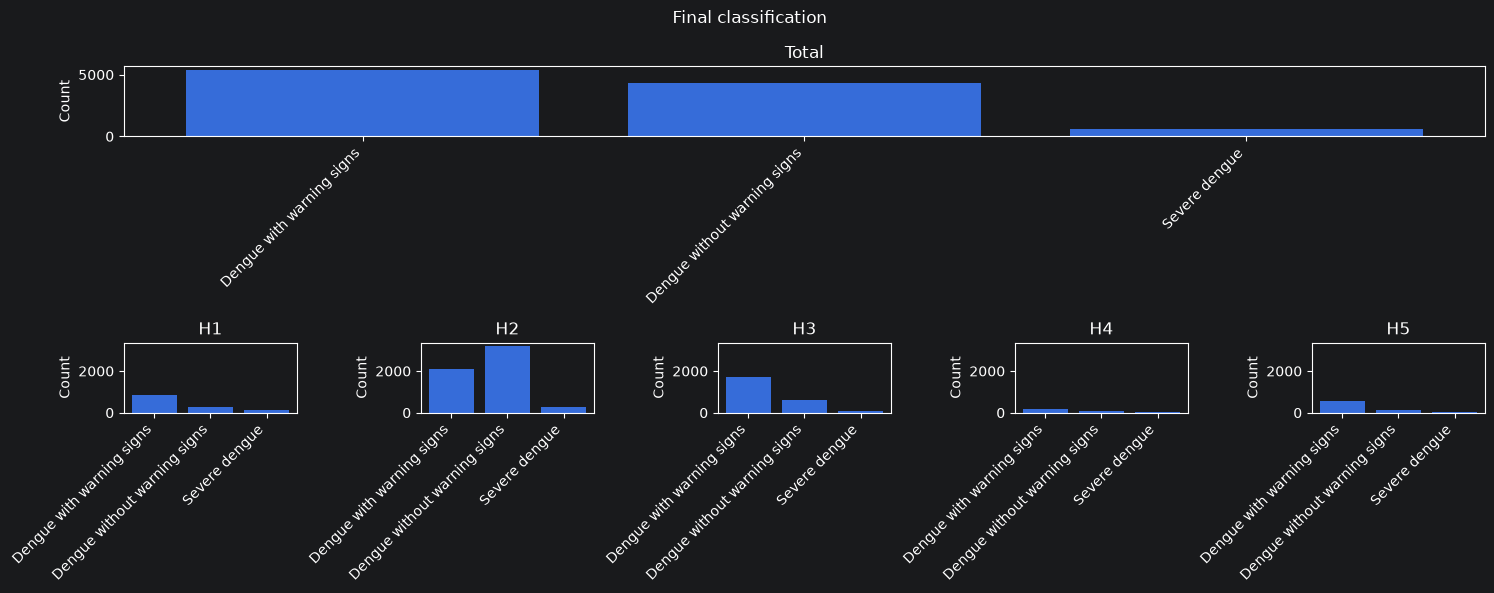

In [11]:
plot_distribution_by_site(
    df,
    column="final_classification",
    site_column="institution",
    title="Final classification",
    normalize=False,
)

### 3.4. Hospitalized

Whether the patient was hospitalized.

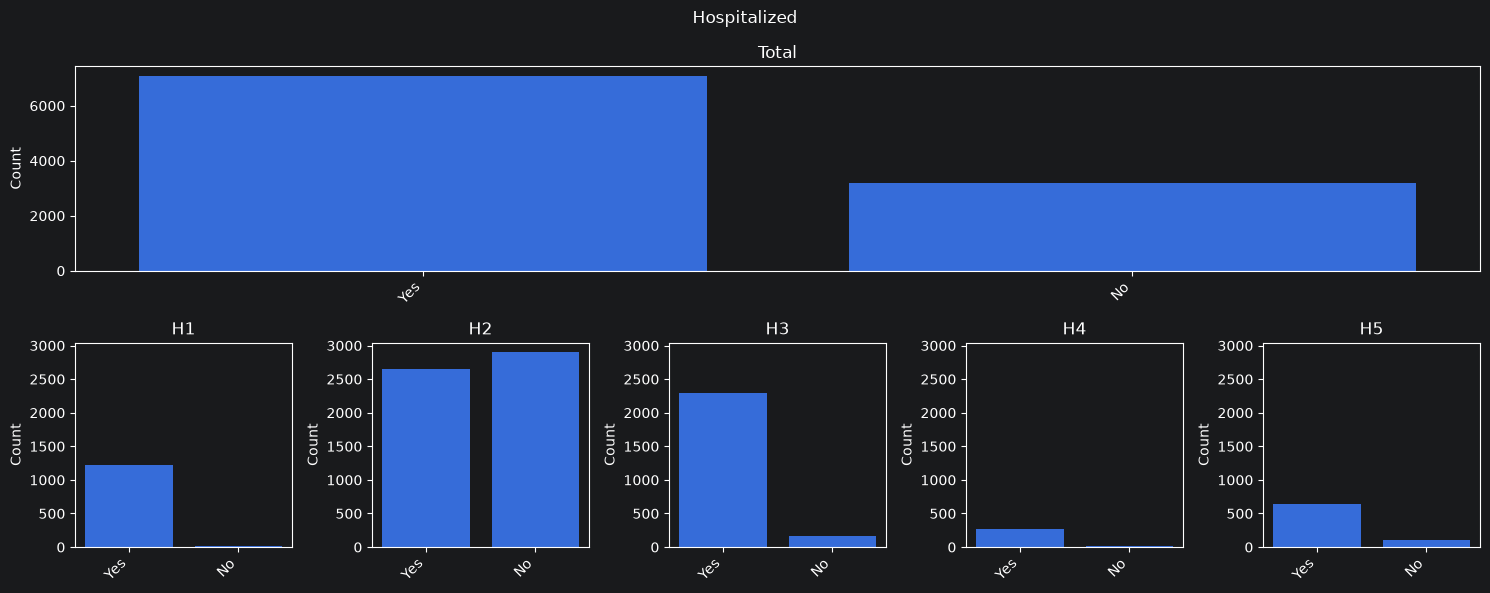

In [12]:
plot_distribution_by_site(
    df, column="hospitalized", site_column="institution", title="Hospitalized", normalize=False
)

### 3.5. Outcome

Patient's final outcome: alive or dead.

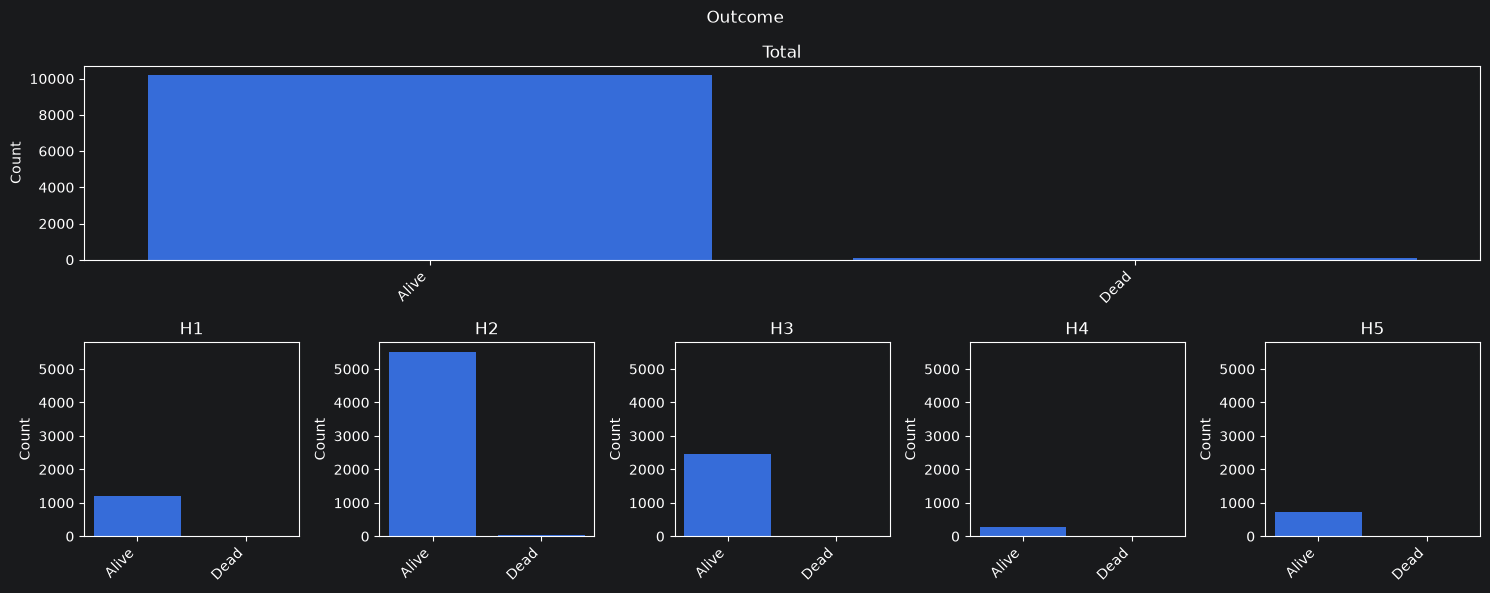

In [13]:
plot_distribution_by_site(
    df, column="outcome", site_column="institution", title="Outcome", normalize=False
)